## scRNA Notebook 2: Batch Effects and Integration

We extend single-sample analysis to a multi-dataset scenario — a common situation in real research where data from different experiments, labs, or sequencing runs must be combined.

## What are batch effects?

When cells are processed and sequenced in separate batches, technical variation is introduced that has nothing to do with biology. Common sources include:

- Differences in sequencing depth between runs
- Reagent lot-to-lot variation
- Differences in handling time, temperature, or library preparation protocol

The result: cells from different batches separate in PCA/UMAP space even if they are biologically identical. If uncorrected, this technical structure can be mistaken for real biology.

## What we will do

1. Combine two PBMC datasets and observe batch effects
2. Apply three integration methods: Harmony, Scanorama, and scVI
3. Compare the methods visually
4. Verify that biological signal is preserved after integration — a step that is just as important as the correction itself

---
## 1. Load Data
---

In [1]:
import scanpy as sc
import scanpy.external as sce
import numpy as np
import scipy.sparse as sp


In [2]:
# Load pbmc3k — real 10x PBMC data
pbmc3k = sc.datasets.pbmc3k()

# Simulate a second batch using the same dataset with added technical variation.
# In a real analysis this would be an independent experiment (e.g. pbmc68k from 10x).
# We simulate it here to keep the notebook self-contained without extra downloads.
np.random.seed(42)
pbmc68k = sc.datasets.pbmc3k().copy()

# Simulate a realistic batch effect: per-gene capture efficiency differences.
# A lognormal distribution (sigma=1.5) gives a wide spread of gene-level factors,
# some genes 10-20x higher or lower than in batch 1. This mirrors real platform
# differences (e.g., different probe sets or library protocols).
# Cell-level depth scaling is removed by normalize_total; gene-level systematic
# biases persist because normalization only equalizes each cell's total counts.
gene_factors = np.random.lognormal(mean=0, sigma=1.5, size=pbmc68k.shape[1]).astype(np.float32)
pbmc68k.X = pbmc68k.X.multiply(gene_factors).tocsr()

# Assign batch labels
pbmc3k.obs["batch"] = "pbmc3k"
pbmc68k.obs["batch"] = "pbmc68k"

print(f"pbmc3k:  {pbmc3k.shape}")
print(f"pbmc68k: {pbmc68k.shape}")

pbmc3k:  (2700, 32738)
pbmc68k: (2700, 32738)


---
## 2. Align Gene Space
---

Different sequencing experiments may measure different gene sets — due to platform differences, upstream QC filtering, or gene panel design. Before combining datasets, we must restrict both to the genes they share in common.

In this simulated case, both datasets originate from the same source so the intersection is the full gene set. In a real multi-dataset workflow this step is not optional.

---
## 3. Merge Datasets
---

In [3]:
common_genes = pbmc3k.var_names.intersection(pbmc68k.var_names)
pbmc3k = pbmc3k[:, common_genes].copy()
pbmc68k = pbmc68k[:, common_genes].copy()

print(f"Shared genes: {len(common_genes)}")

Shared genes: 32738


---
## 4. Preprocess
---

Normalize, log-transform, select highly variable genes, scale, and run PCA. We work on the merged object so preprocessing is consistent across both batches.

In [ ]:
import anndata as ad

adata = ad.concat(
    {"pbmc3k": pbmc3k, "pbmc68k": pbmc68k},
    label="batch"
)
adata.obs_names_make_unique()

# Store raw counts before any normalization — scVI requires count data,
# not log-normalized or scaled values.
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Save a full-gene log-normalized copy for CellTypist (section 12).
# CellTypist requires log-normalized expression across all genes —
# not HVG-subset, not scaled. We save here before both of those transforms.
adata_ct = adata.copy()

sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Pin known marker genes so they survive the HVG subset regardless of rank.
# The batch simulation inflates variance in arbitrary genes; these markers are
# needed for biological validation in section 11.
for g in ["CD3D", "MS4A1", "LYZ", "GNLY"]:
    if g in adata.var_names:
        adata.var.loc[g, "highly_variable"] = True

adata = adata[:, adata.var.highly_variable].copy()

sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata)
sc.tl.umap(adata)

# Store the uncorrected UMAP for later comparison
adata.obsm["X_umap_uncorrected"] = adata.obsm["X_umap"].copy()

print(f"Combined: {adata.shape}")

---
## 5. Observe Batch Effects
---

With standard PCA/UMAP, cells from different batches often separate by technical origin rather than biology. The plot below shows whether the two batches overlap (good) or form distinct islands (batch effect present).

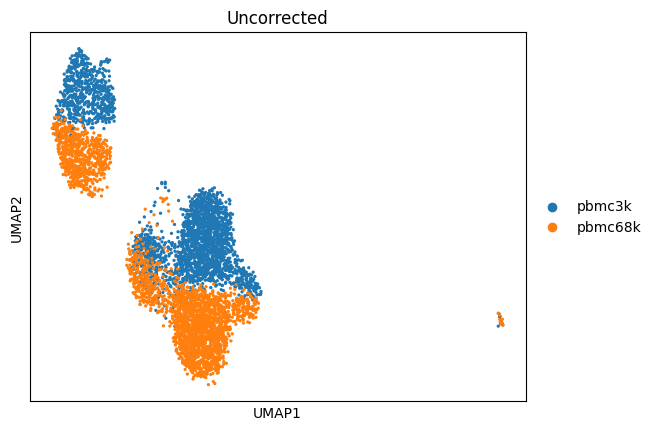

In [5]:
adata.obsm["X_umap"] = adata.obsm["X_umap_uncorrected"]
sc.pl.umap(adata, color="batch", title="Uncorrected")

At this stage, cells often separate by dataset rather than biology.

This is the batch effect problem:
- technical variation dominates structure
- biological signal is partially obscured

---
## 6. Integration Method 1 — Harmony
---

Harmony works in PCA space. It iteratively adjusts the PCA embedding so that cells from different batches with the same cell type land in the same region. It does not modify the gene expression matrix — only the low-dimensional representation.

**Strengths:** fast, simple to apply, works well when batch effects are moderate  
**Limitation:** operates purely in PCA space; may underperform on very large or complex batch effects

2026-04-14 17:04:50,994 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-04-14 17:04:50,995 - harmonypy - INFO -   Parameters:
2026-04-14 17:04:50,995 - harmonypy - INFO -     max_iter_harmony: 10
2026-04-14 17:04:50,995 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-14 17:04:50,995 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-14 17:04:50,996 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-14 17:04:50,996 - harmonypy - INFO -     nclust: 100
2026-04-14 17:04:50,996 - harmonypy - INFO -     block_size: 0.05
2026-04-14 17:04:50,996 - harmonypy - INFO -     lamb: [1. 1.]
2026-04-14 17:04:50,996 - harmonypy - INFO -     theta: [2. 2.]
2026-04-14 17:04:50,997 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-14 17:04:50,997 - harmonypy - INFO -     verbose: True
2026-04-14 17:04:50,997 - harmonypy - INFO -     random_state: 0
2026-04-14 17:04:50,997 - harmonypy - INFO -   Data: 50 PCs × 5400 cells
2026-04-14 17:04:50,997 - harmonypy - INFO 

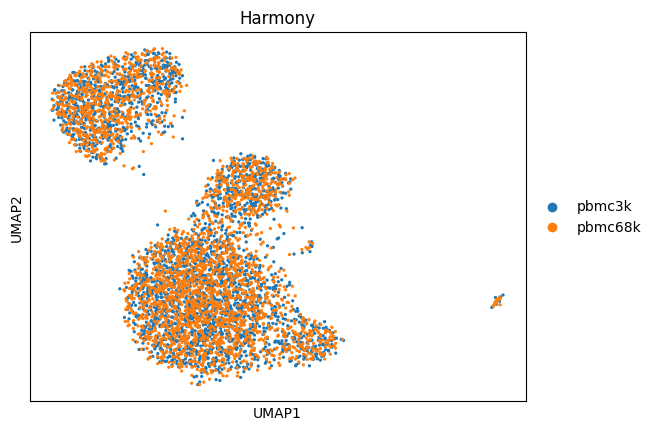

In [6]:
import harmonypy as hm

ho = hm.run_harmony(
    adata.obsm["X_pca"].astype("float64"),
    adata.obs,
    "batch"
)
adata.obsm["X_pca_harmony"] = ho.Z_corr

sc.pp.neighbors(adata, use_rep="X_pca_harmony")
sc.tl.umap(adata)
adata.obsm["X_umap_harmony"] = adata.obsm["X_umap"].copy()

sc.pl.umap(adata, color="batch", title="Harmony")

---
## 7. Integration Method 2 — Scanorama
---

Scanorama treats batch integration as a panorama stitching problem. It finds matching cell pairs across batches (like overlapping regions in adjacent photos), corrects for the offset between them, and merges them into a shared embedding.

**Strengths:** can integrate more than two batches simultaneously; does not require all cell types to be present in every batch  
**Limitation:** requires well-overlapping datasets; performance degrades when batches share very few cell types

[[0.         0.97666667]
 [0.         0.        ]]
Processing datasets pbmc3k <=> pbmc68k


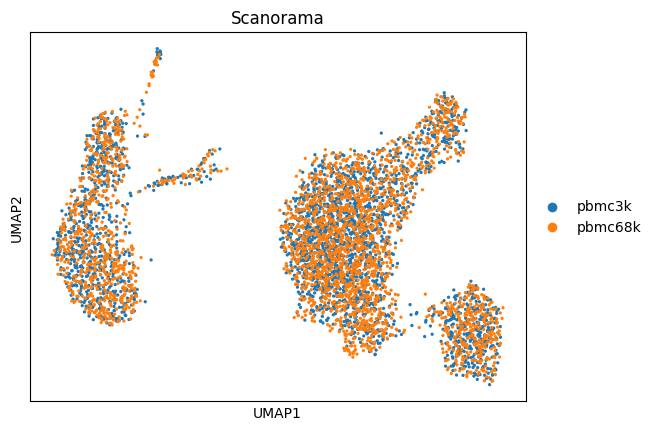

In [7]:
import scanpy.external as sce

sce.pp.scanorama_integrate(adata, key="batch")

sc.pp.neighbors(adata, use_rep="X_scanorama")
sc.tl.umap(adata)
adata.obsm["X_umap_scanorama"] = adata.obsm["X_umap"].copy()

sc.pl.umap(adata, color="batch", title="Scanorama")

---
## 8. Integration Method 3 — scVI
---

scVI (single-cell Variational Inference) is a deep generative model. It learns a probabilistic latent representation of each cell, explicitly modeling both biological variation and batch as separate factors. It accounts for the count nature of sequencing data directly.

**Strengths:** most principled statistical treatment; handles complex, high-dimensional batch effects well; the latent representation can be reused for downstream tasks  
**Limitation:** slower to train; requires a GPU for large datasets; more of a black box than linear methods

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/gavinoliver/git_repos/scrna-basics/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/gavinoliver/git_repos/scrna-basics/.venv/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/gavinoliver/git_repos/scrna-basics/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `nu

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


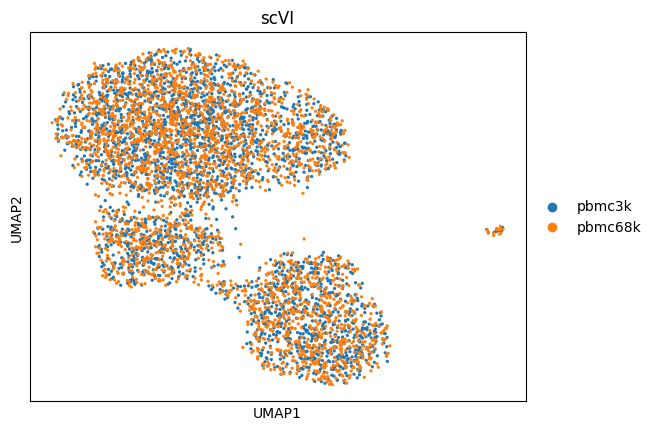

In [8]:
import warnings
warnings.filterwarnings("ignore", module="scvi")
import scvi

# scVI is a generative model that expects raw counts, not scaled values.
# We pass the counts layer stored before normalization.
scvi.model.SCVI.setup_anndata(adata, batch_key="batch", layer="counts")
model = scvi.model.SCVI(adata)
model.train()

adata.obsm["X_scVI"] = model.get_latent_representation()

sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)
adata.obsm["X_umap_scvi"] = adata.obsm["X_umap"].copy()

sc.pl.umap(adata, color="batch", title="scVI")

---
## 9. Compare Methods Side-by-Side
---

We now view all four embeddings together. Good integration shows the two batches interleaved throughout the UMAP rather than forming separate islands.

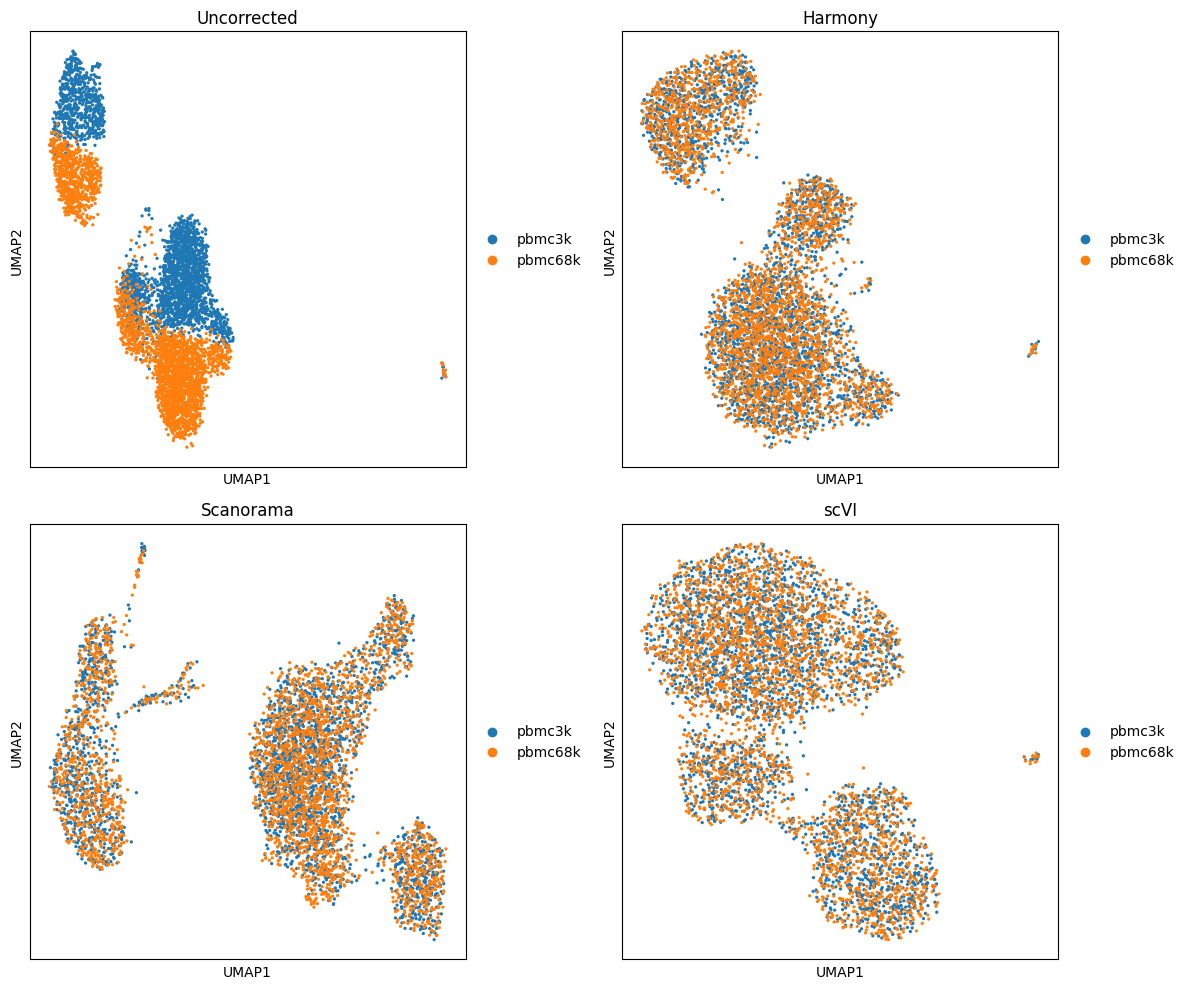

In [9]:
import matplotlib.pyplot as plt

methods = [
    ("X_umap_uncorrected", "Uncorrected"),
    ("X_umap_harmony",     "Harmony"),
    ("X_umap_scanorama",   "Scanorama"),
    ("X_umap_scvi",        "scVI"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (key, title) in zip(axes.flat, methods):
    adata.obsm["X_umap"] = adata.obsm[key]
    sc.pl.umap(adata, color="batch", title=title, ax=ax, show=False)

plt.tight_layout()
plt.show()

---
## 10. Interpretation
---

Visual batch mixing tells us that technical variation has been reduced — but it does not tell us whether the biology survived. A method that overcorrects can collapse distinct cell types into a single cloud. That would look "good" by a mixing metric but would be analytically useless.

The next section checks this directly.

### What to expect from each method

**Uncorrected** — batches separate; biological structure is present but confounded  
**Harmony** — good mixing for moderate batch effects; fast; interpretable  
**Scanorama** — robust across multiple batches; handles partial cell type overlap well  
**scVI** — typically the strongest correction; best for complex scenarios; more expensive to run

No single method is universally best. The right choice depends on dataset complexity, the severity of batch effects, and downstream needs.

---
## 11. Biological Signal Retention
---

Batch correction is only useful if the underlying biology is preserved. We check this for all four embeddings using two approaches:

1. **Known marker genes** — well-established PBMC markers should show distinct, localized expression on every method's UMAP. Diffuse expression signals overcorrection.

2. **Clustering + batch composition** — we cluster cells on each integrated embedding and check that (a) clusters reflect biology rather than batch, and (b) each cluster contains cells from both batches in roughly equal proportions.

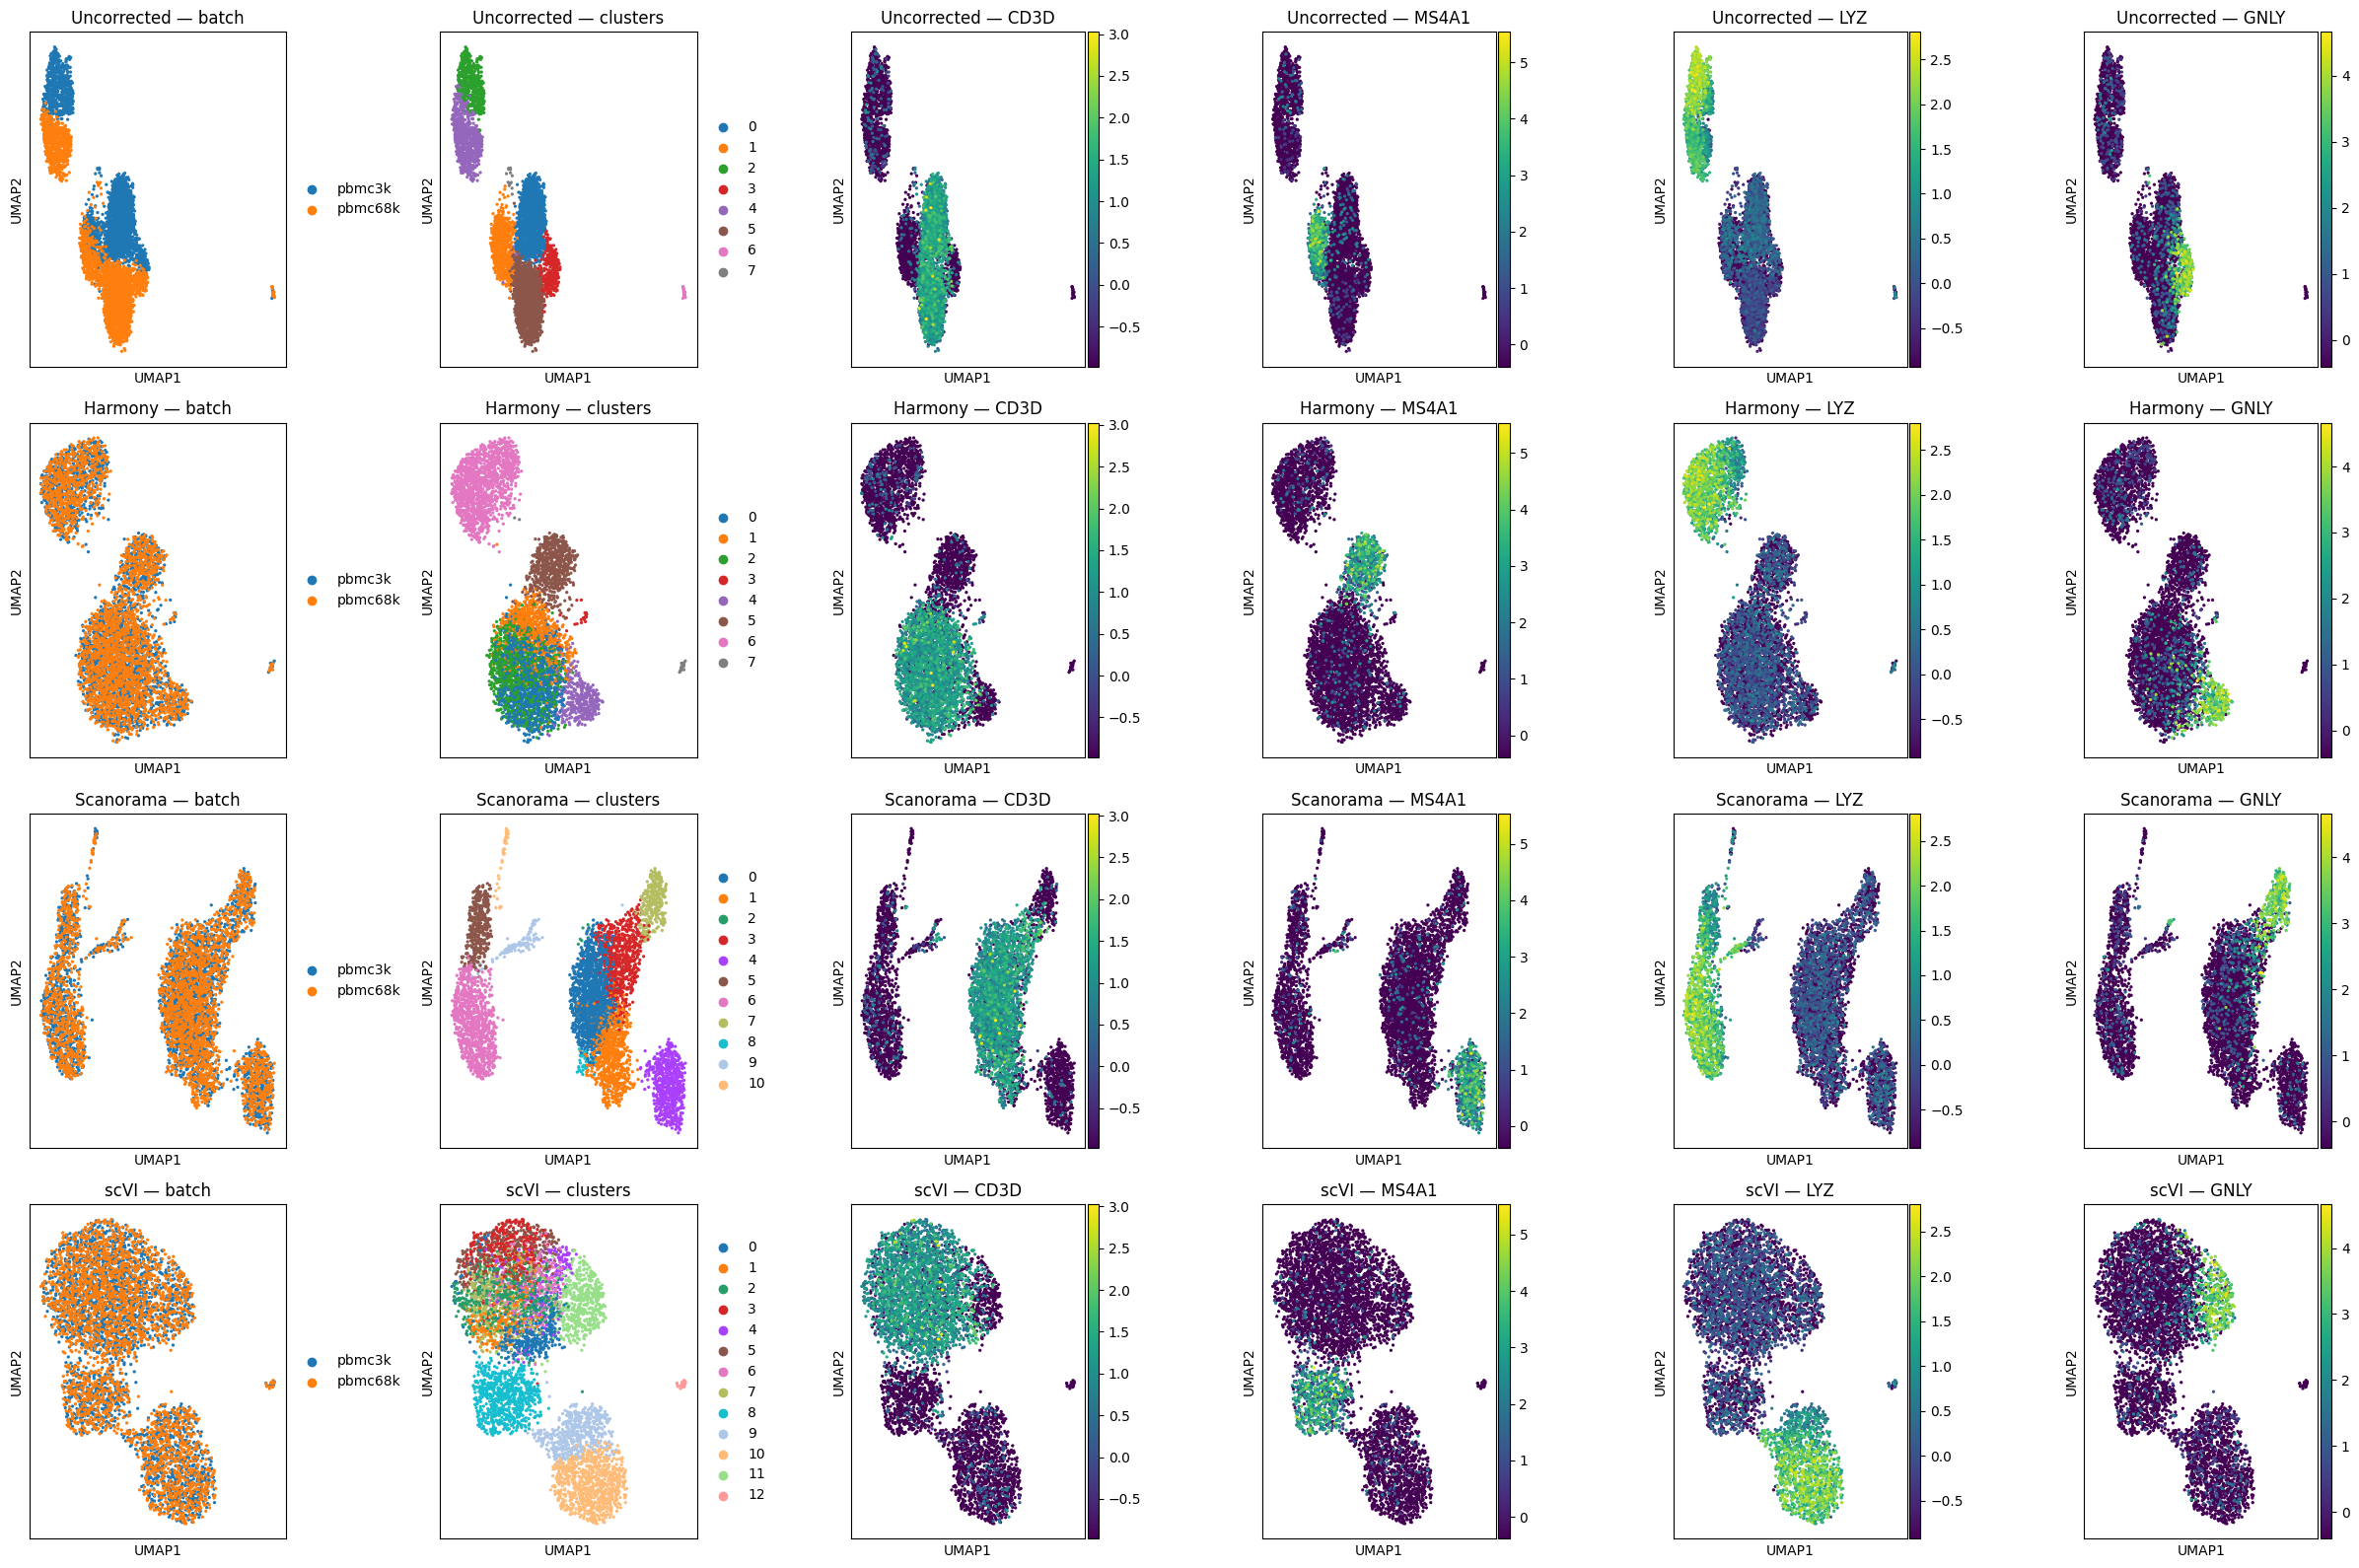

In [10]:
import matplotlib.pyplot as plt

marker_candidates = {
    "T cells":   "CD3D",
    "B cells":   "MS4A1",
    "Monocytes": "LYZ",
    "NK cells":  "GNLY",
}
markers = {k: v for k, v in marker_candidates.items() if v in adata.var_names}

methods = [
    ("X_umap_uncorrected", "X_pca",          "Uncorrected", "leiden_uncorrected"),
    ("X_umap_harmony",     "X_pca_harmony",   "Harmony",     "leiden_harmony"),
    ("X_umap_scanorama",   "X_scanorama",     "Scanorama",   "leiden_scanorama"),
    ("X_umap_scvi",        "X_scVI",          "scVI",        "leiden_scvi"),
]

# Cluster each embedding independently
for _, rep_key, _, leiden_key in methods:
    sc.pp.neighbors(adata, use_rep=rep_key)
    sc.tl.leiden(adata, key_added=leiden_key, flavor="igraph", n_iterations=2, directed=False)

# Plot: rows = methods, columns = batch | clusters | markers
marker_genes = list(markers.values())
ncols = 2 + len(marker_genes)

fig, axes = plt.subplots(len(methods), ncols, figsize=(4 * ncols, 4 * len(methods)))

for row, (umap_key, _, method_name, leiden_key) in enumerate(methods):
    adata.obsm["X_umap"] = adata.obsm[umap_key]
    sc.pl.umap(adata, color="batch",    ax=axes[row, 0], show=False, title=f"{method_name} — batch")
    sc.pl.umap(adata, color=leiden_key, ax=axes[row, 1], show=False, title=f"{method_name} — clusters")
    for col, gene in enumerate(marker_genes):
        sc.pl.umap(adata, color=gene, ax=axes[row, 2 + col], show=False, title=f"{method_name} — {gene}")

plt.tight_layout()
plt.show()

In [11]:
# For each method, show what fraction of each cluster comes from each batch.
# A well-integrated dataset has roughly equal batch proportions in every cluster.
for _, _, method_name, leiden_key in methods:
    batch_props = (
        adata.obs
        .groupby([leiden_key, "batch"], observed=True)
        .size()
        .unstack(fill_value=0)
        .apply(lambda x: x / x.sum(), axis=1)
        .round(2)
    )
    print(f"\n{method_name} — batch composition per cluster:")
    print(batch_props)


Uncorrected — batch composition per cluster:
batch               pbmc3k  pbmc68k
leiden_uncorrected                 
0                     1.00     0.00
1                     0.50     0.50
2                     1.00     0.00
3                     0.51     0.49
4                     0.17     0.83
5                     0.04     0.96
6                     0.52     0.48
7                     0.50     0.50

Harmony — batch composition per cluster:
batch           pbmc3k  pbmc68k
leiden_harmony                 
0                  0.5      0.5
1                  0.5      0.5
2                  0.5      0.5
3                  0.5      0.5
4                  0.5      0.5
5                  0.5      0.5
6                  0.5      0.5
7                  0.5      0.5

Scanorama — batch composition per cluster:
batch             pbmc3k  pbmc68k
leiden_scanorama                 
0                   0.53     0.47
1                   0.45     0.55
2                   0.33     0.67
3                 

## What to look for

**Marker genes** — each marker should be concentrated in a distinct region of the UMAP for every method. If CD3D (T cells) and LYZ (monocytes) appear spread evenly across all clusters, the integration has collapsed biologically distinct populations.

**Cluster batch composition** — in a well-integrated dataset, each cluster should contain cells from both batches in roughly equal proportions (~50/50 here, since the datasets are the same size). A cluster that is 90%+ from one batch is a sign that batch structure remains.

**Comparing methods** — the uncorrected embedding will show batch-skewed clusters; the integration methods should progressively improve mixing while keeping marker expression localized. If a method mixes batches perfectly but marker expression becomes diffuse, it has overcorrected.

---
## 12. Automated Cell Type Annotation Across Methods
---

Marker gene inspection (section 11) tells us whether a handful of known genes are correctly localized. CellTypist goes further: it applies a pre-trained classifier to the full transcriptome of every cell, assigning it to a labeled immune cell type from a curated atlas.

We run CellTypist once on the full log-normalized data saved in section 4 (`adata_ct`). Because that object is independent of any batch-correction step, the per-cell labels reflect the underlying biology without any embedding-specific bias.

We then project those labels onto each of the four UMAP embeddings. The question for each method is: **do cells of the same type form coherent, spatially concentrated groups?**

- If yes → biology is preserved; cells that share a transcriptional identity land near each other regardless of which batch they came from
- If the same cell type is scattered across the UMAP → the integration has either collapsed distinct populations or introduced new artificial structure

This is a stricter test than marker genes alone because it uses the entire transcriptome profile, not just four genes.

In [ ]:
import celltypist
from celltypist import models

# CellTypist's majority_voting step uses a kNN graph to smooth per-cell predictions
# into coherent cluster-level labels. We compute neighbors on the full log-normalized
# gene space — independent of any batch-correction embedding.
sc.pp.neighbors(adata_ct)

pred = celltypist.annotate(
    adata_ct,
    model='Immune_All_Low.pkl',
    majority_voting=True
)
adata_ct.obs["celltypist_labels"] = pred.predicted_labels["majority_voting"]

print("Cell type labels assigned:")
print(adata_ct.obs["celltypist_labels"].value_counts())

In [ ]:
methods = [
    ("X_umap_uncorrected", "Uncorrected"),
    ("X_umap_harmony",     "Harmony"),
    ("X_umap_scanorama",   "Scanorama"),
    ("X_umap_scvi",        "scVI"),
]

for umap_key, title in methods:
    # Project this method's embedding onto adata_ct so sc.pl.umap renders correctly
    adata_ct.obsm["X_umap"] = adata.obsm[umap_key]
    sc.pl.umap(
        adata_ct,
        color="celltypist_labels",
        title=f"{title} — CellTypist annotation",
        legend_loc="on data",
        legend_fontsize=6,
    )

## What to look for

**Spatial coherence** — each cell type label should form a compact, concentrated region. If T cells (CD4+/CD8+ subtypes) or monocyte populations are scattered randomly across the UMAP, the embedding has destroyed the transcriptional neighborhoods that define those identities.

**Consistency across methods** — the same broad populations (T cells, B cells, monocytes, NK cells) should appear in roughly the same relative arrangement in every corrected embedding. Large-scale reordering of populations between methods signals that one or more methods are distorting biological structure.

**Uncorrected as baseline** — the uncorrected UMAP will show the same cell types but they will be spatially duplicated: each population may appear twice (once per batch) rather than merging into a single island. Well-integrated methods collapse each cell type into a single coherent group.

**Comparing to section 11** — cross-reference CellTypist labels with the marker gene plots. CD3D-high regions should map to T cell labels; LYZ-high regions to monocyte labels. Disagreement between automated labels and known markers is a signal worth investigating.